# Verificação de precipitação no RS — WeatherNext 2 × INMET × IMERG

Compara a chuva **observada** com a **prevista** pelo WeatherNext 2, tendo como caso de
referência a cheia de **abril–maio de 2024** no Rio Grande do Sul.

Três fontes:
- **INMET** — estações automáticas, tratadas como pontos (observação de referência).
- **IMERG (GPM)** — satélite (~0,1°), usado como **malha de referência** (verdade em grade).
- **WeatherNext 2** — modelo de IA (~0,25°, passos de 6 h): **média** e os **64 membros**.

## Organização
- **Seções 0–4:** setup comum (dados INMET, pontos das estações, controle de qualidade e o
  motor de verificação). Rode uma vez.
- **Seção 5:** WeatherNext 2 (média) — métricas por horizonte.
- **Seção 6:** WeatherNext 2 (64 membros) — dispersão do ensemble e erro por estação/horizonte.
- **Seção 7:** comparação espacial em malha (isoietas e probabilidade de excedência) contra o IMERG.

## Desempenho
- A amostragem da grade nos pontos é **server-side no Earth Engine**: uma `FeatureCollection`
  de pontos + `reduceRegions` (todas as estações numa passada por imagem), exportada por
  `Export.table.toDrive`. O pandas entra só no pós-processamento.
- O INMET diário é **cacheado em parquet**; os exports do WeatherNext e os campos das matrizes
  ficam em cache no Drive — trocar só o código de figura não refaz a extração.


## Como não re-baixar tudo a cada mudança de código

O que é pesado (exports do Earth Engine e os campos das matrizes) fica **cacheado no Drive**:

- **INMET diário** → cache em parquet (`carregar_precipitacao_diaria`).
- **Exports do WeatherNext** → `exportar_e_ler` reusa o CSV se já existir. Só re-exporta com `forcar=True`.
- **Campos das matrizes** → guardados num `.pkl`; só re-baixa com `forcar=True`.




## 0. Setup





In [ ]:

!pip install -q geemap


In [ ]:
import os
import re
import time

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
ee.Authenticate()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ---- Caminhos ----
CAMINHO_CSV      = '/content/drive/MyDrive/geoprocessamento/consolidado_precipitacao_rs.csv'
CAMINHO_PARQUET  = '/content/drive/MyDrive/geoprocessamento/precipitacao_diaria.parquet'

# ---- Earth Engine ----
PROJECT_ID = 'projetoee'

# ---- INMET ----
MIN_HORAS_DIA = 20          # horas válidas mínimas para o total diário do dia valer

# ---- WeatherNext 2 ----
WN2_MEDIA    = 'projects/gcp-public-data-weathernext/assets/weathernext_2_0_0_mean'
WN2_MEMBROS  = 'projects/gcp-public-data-weathernext/assets/weathernext_2_0_0'
BANDA_PRECIP = 'total_precipitation_6hr'   # janelas de 6 h, em metros (somar; NÃO desacumular)
ESCALA_WN2   = 27830                       # ~0,25° (resolução nativa do WN2)

# ---- IMERG (satélite, malha de referência) ----
IMERG_ASSET  = 'NASA/GPM_L3/IMERG_V07'
ESCALA_IMERG = 11132                       # ~0,1°

# ---- Limite do estado (asset IBGE) ----
UF_ASSET = 'projects/helpful-rope-457220-n0/assets/BR_2025'
UF_SIGLA = 'RS'


In [ ]:
ee.Initialize(project=PROJECT_ID)

# Impede que o geemap procure GOOGLE_MAPS_API_KEY nos Colab Secrets.
try:
    from google.colab import userdata as _userdata
    _userdata.get = lambda *args, **kwargs: None
except Exception:
    pass

CAIXA_RS = ee.Geometry.Rectangle([-58.0, -34.0, -49.0, -27.0])


## 1. INMET — leitura, limpeza e agregação diária

`N_HORAS_VALIDAS` conta as horas com leitura no dia (inclui 0 mm; branco / `-` / `NA` viram NaN).
`PRECIP_DIARIA_MM` é a soma das horas do dia (calendário **UTC**, pois a hora do INMET é UTC).

Na primeira vez o CSV consolidado é lido e agregado; depois fica **cacheado em parquet** e a leitura passa a ser instantânea.


In [ ]:
def para_float_brasileiro(coluna):
    """Converte texto com vírgula decimal (padrão brasileiro) para float."""
    return (
        coluna.astype(str).str.strip()
        .replace({'': np.nan, '-': np.nan, 'nan': np.nan, 'None': np.nan})
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )


def carregar_precipitacao_diaria():
    """Devolve o INMET agregado por dia. Usa o cache parquet se existir."""
    if os.path.exists(CAMINHO_PARQUET):
        print('Lendo cache parquet:', CAMINHO_PARQUET)
        return pd.read_parquet(CAMINHO_PARQUET)

    print('Cache não encontrado. Lendo o CSV consolidado...')
    bruto = pd.read_csv(CAMINHO_CSV, sep=';', dtype=str, encoding='utf-8-sig', low_memory=False)

    horaria = bruto.copy()
    for coluna in ['LATITUDE', 'LONGITUDE', 'ALTITUDE', 'PRECIPITACAO_MM']:
        if coluna in horaria.columns:
            horaria[coluna] = para_float_brasileiro(horaria[coluna])

    # Valor negativo
    horaria.loc[horaria['PRECIPITACAO_MM'] < 0, 'PRECIPITACAO_MM'] = np.nan

    # DATA = 'AAAA/MM/DD'  |  HORA = 'HHMM UTC'
    hora_extraida = horaria['HORA'].str.extract(r'(\d{4})')[0]
    horaria['DATETIME'] = pd.to_datetime(
        horaria['DATA'].str.strip() + ' ' + hora_extraida,
        format='%Y/%m/%d %H%M', errors='coerce',
    )
    horaria['ANO'] = horaria['DATETIME'].dt.year
    horaria['MES'] = horaria['DATETIME'].dt.month
    horaria['DIA'] = horaria['DATETIME'].dt.day
    horaria['ESTACAO'] = horaria['ESTACAO'].astype(str).str.strip()

    diaria = (
        horaria
        .groupby(['UF', 'ESTACAO', 'LATITUDE', 'LONGITUDE', 'ALTITUDE', 'ANO', 'MES', 'DIA'],
                 observed=True)
        .agg(PRECIP_DIARIA_MM=('PRECIPITACAO_MM', 'sum'),
             N_HORAS_VALIDAS=('PRECIPITACAO_MM', 'count'))
        .reset_index()
    )
    diaria['DATA'] = pd.to_datetime(
        diaria[['ANO', 'MES', 'DIA']].rename(columns={'ANO': 'year', 'MES': 'month', 'DIA': 'day'})
    )
    diaria.to_parquet(CAMINHO_PARQUET, index=False)
    print('Cache salvo em', CAMINHO_PARQUET)
    return diaria


precipitacao_diaria = carregar_precipitacao_diaria()
print(f'Registros diários: {len(precipitacao_diaria):,} | estações: {precipitacao_diaria["ESTACAO"].nunique()}')
precipitacao_diaria.head(3)


Lendo cache parquet: /content/drive/MyDrive/geoprocessamento/precipitacao_diaria.parquet
Registros diários: 51,951 | estações: 69


,UF,ESTACAO,LATITUDE,LONGITUDE,ALTITUDE,ANO,MES,DIA,PRECIP_DIARIA_MM,N_HORAS_VALIDAS,DATA
0,RS,ACEGUA,-31.874722,-54.119722,271.0,2025,9,17,0.0,0,2025-09-17
1,RS,ACEGUA,-31.874722,-54.119722,271.0,2025,9,18,0.0,0,2025-09-18
2,RS,ACEGUA,-31.874722,-54.119722,271.0,2025,9,19,0.0,0,2025-09-19


## 2. Pontos das estações (Earth Engine)

As coordenadas vêm do  CSV.


In [ ]:
estacoes_com_coordenada = (
    precipitacao_diaria
    .dropna(subset=['LATITUDE', 'LONGITUDE'])
    .groupby('ESTACAO', as_index=False)
    .agg(LATITUDE=('LATITUDE', 'first'), LONGITUDE=('LONGITUDE', 'first'))
)


def ponto_da_estacao(nome_estacao):
    """Ponto (lon, lat) da estação, a partir das coordenadas do CSV."""
    encontrada = estacoes_com_coordenada[estacoes_com_coordenada['ESTACAO'] == nome_estacao]
    if encontrada.empty:
        raise ValueError(f"Estação '{nome_estacao}' não encontrada.")
    linha = encontrada.iloc[0]
    return ee.Geometry.Point([float(linha['LONGITUDE']), float(linha['LATITUDE'])])


def pontos_das_estacoes(nomes_estacoes):
    """FeatureCollection com um ponto por estação (usada pelo reduceRegions)."""
    return ee.FeatureCollection([
        ee.Feature(ponto_da_estacao(nome), {'estacao': nome})
        for nome in nomes_estacoes
    ])


print(f'{len(estacoes_com_coordenada)} estações com coordenada.')


69 estações com coordenada.


## 3. Controle de qualidade — quais estações entram

Filtro por janela de datas + critérios em **%** (que escalam com a janela). "Dentro do RS" é testado
pelo polígono do IBGE. A saída é `estacoes_aprovadas`, que alimenta as extrações.


In [ ]:
# ============ AJUSTE   ============
QC_DATA_INICIO       = '2024-04-01'
QC_DATA_FIM          = '2024-05-15'
QC_MIN_HORAS_PCT     = 0.80    # % das 24 h para um dia contar como válido
QC_MIN_COBERTURA_PCT = 0.50    # % dos dias da janela que a estação precisa cobrir
QC_MAX_MM_DIA        = 300     # descarta estação com algum dia acima disso (erro de sensor)
# =======================================================================

rs_feature = ee.FeatureCollection(UF_ASSET).filter(ee.Filter.eq('SIGLA_UF', UF_SIGLA))
rs_geometria = rs_feature.geometry()
print('Feições do RS no asset:', rs_feature.size().getInfo(), '(tem que dar 1)')

inicio = pd.Timestamp(QC_DATA_INICIO)
fim = pd.Timestamp(QC_DATA_FIM)
total_dias = (fim - inicio).days + 1
min_horas = round(QC_MIN_HORAS_PCT * 24)
print(f'Janela {QC_DATA_INICIO}..{QC_DATA_FIM} = {total_dias} dias | '
      f'dia válido >= {min_horas} h | cobertura mínima {QC_MIN_COBERTURA_PCT:.0%}')

na_janela = precipitacao_diaria.copy()
na_janela['ESTACAO'] = na_janela['ESTACAO'].astype(str).str.strip()
na_janela['DATA'] = pd.to_datetime(na_janela['DATA'])
na_janela = na_janela[na_janela['DATA'].between(inicio, fim)]
na_janela['dia_valido'] = na_janela['N_HORAS_VALIDAS'] >= min_horas
na_janela['dia_com_chuva'] = na_janela['PRECIP_DIARIA_MM'] > 0

inventario = (
    na_janela.groupby('ESTACAO')
    .agg(dias_validos=('dia_valido', 'sum'),
         dias_com_chuva=('dia_com_chuva', 'sum'),
         maior_chuva_dia=('PRECIP_DIARIA_MM', 'max'))
    .reset_index()
)
inventario['cobertura'] = inventario['dias_validos'] / total_dias

coordenadas = estacoes_com_coordenada.copy()
coordenadas['ESTACAO'] = coordenadas['ESTACAO'].astype(str).str.strip()
inventario = (
    inventario
    .merge(coordenadas[['ESTACAO', 'LATITUDE', 'LONGITUDE']], on='ESTACAO', how='left')
    .rename(columns={'LATITUDE': 'lat', 'LONGITUDE': 'lon'})
)

# Está dentro do RS? (testa os pontos contra o polígono do estado)
pontos_para_teste = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([linha.lon, linha.lat]), {'ESTACAO': linha.ESTACAO})
    for linha in inventario.dropna(subset=['lat', 'lon']).itertuples()
])
dentro_do_rs = pontos_para_teste.filterBounds(rs_geometria).aggregate_array('ESTACAO').getInfo()
inventario['dentro_do_rs'] = inventario['ESTACAO'].isin(dentro_do_rs)


def classificar_estacao(linha):
    if pd.isna(linha['lat']):
        return 'sem coordenada'
    if not linha['dentro_do_rs']:
        return 'fora do RS'
    if linha['cobertura'] < QC_MIN_COBERTURA_PCT:
        return f"pouca cobertura ({linha['cobertura']:.0%})"
    if linha['maior_chuva_dia'] > QC_MAX_MM_DIA:
        return f"valor suspeito ({linha['maior_chuva_dia']:.0f} mm)"
    return 'OK'


inventario['situacao'] = inventario.apply(classificar_estacao, axis=1)
inventario['aprovada'] = inventario['situacao'] == 'OK'

print(inventario['situacao'].value_counts())
estacoes_aprovadas = inventario.loc[inventario['aprovada'], 'ESTACAO'].tolist()
print(f'{len(estacoes_aprovadas)} de {len(inventario)} estações aprovadas.')


Feições do RS no asset: 1 (tem que dar 1)
Janela 2024-04-01..2024-05-15 = 45 dias | dia válido >= 19 h | cobertura mínima 50%
situacao
OK                       41
pouca cobertura (29%)     1
pouca cobertura (2%)      1
pouca cobertura (27%)     1
Name: count, dtype: int64
41 de 44 estações aprovadas.


In [ ]:
# Mapa das estações: verde = aprovada, vermelho = com problema.
def _colecao_de_pontos(tabela):
    return ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([linha.lon, linha.lat]), {'estacao': linha.ESTACAO})
        for linha in tabela.dropna(subset=['lat', 'lon']).itertuples()
    ])

mapa_qc = geemap.Map(center=[-30.0, -53.0], zoom=6)
mapa_qc.addLayer(rs_feature.style(color='000000', fillColor='00000000', width=1), {}, 'RS (limite)')
mapa_qc.addLayer(_colecao_de_pontos(inventario[~inventario['aprovada']]).style(color='red', pointSize=6),
                 {}, f"Com problema ({int((~inventario['aprovada']).sum())})")
mapa_qc.addLayer(_colecao_de_pontos(inventario[inventario['aprovada']]).style(color='green', pointSize=6),
                 {}, f"Aprovadas ({int(inventario['aprovada'].sum())})")
mapa_qc.addLayerControl()
mapa_qc


Map(center=[-30.0, -53.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 4.Verificação

 WeatherNext:
- **extração** (amostra os pontos com `reduceRegions` e exporta o CSV),
- **processamento** (janelas de 6 h → total diário),
- **observação de referência** (INMET),
- **casamento** previsão × observação em "casos" (estação, rodada, lead, data válida),
- **métricas contínuas** (viés, MAE, RMSE, correlação) por horizonte.




In [ ]:
# ---- 4.1 Extração: amostrar a previsão nos pontos das estações ----
def amostrar_previsao_nos_pontos(asset, nomes_estacoes, datas_rodada, com_membro):
    """
    Amostra a banda de precipitação do asset nos pontos das estações, para o ciclo 00Z
    de cada data de rodada. Uma passada por imagem, todas as estações de uma vez.
    """
    colecao = ee.ImageCollection(asset).filterBounds(CAIXA_RS)
    pontos = pontos_das_estacoes(nomes_estacoes)
    datas_texto = [pd.Timestamp(d).strftime('%Y-%m-%d') for d in datas_rodada]

    def por_rodada(data_texto):
        inicio_rodada = ee.Date(data_texto)
        ciclo_00z = colecao.filterDate(inicio_rodada, inicio_rodada.advance(6, 'hour'))

        def amostrar_imagem(imagem):
            amostras = imagem.select(BANDA_PRECIP).reduceRegions(
                collection=pontos, reducer=ee.Reducer.first(), scale=ESCALA_WN2)

            def carimbar(feicao):
                propriedades = {
                    'precip_m': feicao.get('first'),
                    'rodada_ms': imagem.get('system:time_start'),
                    'horas_previsao': imagem.get('forecast_hour'),
                }
                if com_membro:
                    propriedades['membro'] = imagem.get('ensemble_member')
                return feicao.set(propriedades)

            return amostras.map(carimbar)

        return ciclo_00z.map(amostrar_imagem).flatten()

    return (
        ee.FeatureCollection(ee.List(datas_texto).map(por_rodada))
        .flatten()
        .filter(ee.Filter.notNull(['precip_m']))
    )


def ler_csv_do_drive(pasta, arquivo, tentativas=15, espera_segundos=10):
    """
    Lê o CSV exportado, contornando o atraso do Colab para 'enxergar' arquivos que o
    Earth Engine gravou no Drive. Espera, força o remount e tenta de novo.
    """
    caminho = f'/content/drive/MyDrive/{pasta}/{arquivo}.csv'
    for tentativa in range(tentativas):
        if os.path.exists(caminho):
            tabela = pd.read_csv(caminho)
            print('Lido:', caminho, '|', len(tabela), 'linhas')
            return tabela
        print(f'   arquivo ainda não visível, aguardando sincronização do Drive ({tentativa + 1}/{tentativas})...')
        time.sleep(espera_segundos)
        if tentativa == 2:   # depois de ~30 s, força o Colab a re-sincronizar uma vez
            try:
                from google.colab import drive
                drive.mount('/content/drive', force_remount=True)
            except Exception:
                pass
    raise FileNotFoundError(
        f'"{arquivo}.csv" não apareceu em /content/drive/MyDrive/{pasta}/. '
        f'O export terminou (confira em drive.google.com, pasta "{pasta}").')


def exportar_e_ler(feature_collection, pasta, arquivo, seletores, espera_segundos=30, forcar=False):
    """
    Dispara o Export.table.toDrive, espera terminar e lê o CSV de volta (com retry no Drive).
    Se o CSV já existe no Drive e forcar=False, apenas LÊ o cache (não re-exporta) . forcar=True para refazer.
    """
    caminho = f'/content/drive/MyDrive/{pasta}/{arquivo}.csv'
    if not forcar and os.path.exists(caminho):
        tabela = pd.read_csv(caminho)
        print(f'Cache encontrado em {caminho} ({len(tabela)} linhas) — pulando o export. '
              'Use forcar=True para refazer.')
        return tabela

    tarefa = ee.batch.Export.table.toDrive(
        collection=feature_collection,
        description=arquivo, folder=pasta, fileNamePrefix=arquivo,
        fileFormat='CSV', selectors=seletores,
    )
    tarefa.start()
    print('Export iniciado, aguardando...')
    while tarefa.active():
        print('   estado:', tarefa.status().get('state'))
        time.sleep(espera_segundos)
    estado_final = tarefa.status().get('state')
    print('Estado final:', estado_final)
    if estado_final != 'COMPLETED':
        raise RuntimeError(f'O export não concluiu ({estado_final}): {tarefa.status()}')

    return ler_csv_do_drive(pasta, arquivo)


def nome_cache(base, datas_rodada):
    """Nome de arquivo que inclui o período — trocar as datas cria um cache novo automaticamente."""
    inicio = pd.Timestamp(min(datas_rodada)).strftime('%Y%m%d')
    fim = pd.Timestamp(max(datas_rodada)).strftime('%Y%m%d')
    return f'{base}_{inicio}_{fim}'


def previsao_diaria_a_partir_de_6h(tabela_bruta, com_membro):
    """Soma as 4 janelas de 6 h de cada dia (metros -> mm). init = system:time_start (ciclo 00Z)."""
    if tabela_bruta is None or len(tabela_bruta) == 0:
        raise ValueError('Tabela bruta vazia — confira o acesso ao asset e se o período é coberto.')

    dados = tabela_bruta.copy()
    dados['precip_m'] = pd.to_numeric(dados['precip_m'], errors='coerce')
    dados['rodada'] = pd.to_datetime(dados['rodada_ms'], unit='ms', utc=True)
    dados = dados[dados['rodada'].dt.hour == 0]                      # garante só o ciclo 00Z
    dados['horas_previsao'] = pd.to_numeric(dados['horas_previsao'], errors='coerce')
    dados = dados[dados['horas_previsao'].between(1, 360)]
    dados['lead_dias'] = np.ceil(dados['horas_previsao'] / 24).astype(int)   # 1..15
    dados['rodada'] = dados['rodada'].dt.floor('D')

    chaves = ['estacao', 'rodada', 'lead_dias']
    if com_membro:
        dados['membro'] = pd.to_numeric(dados['membro'], errors='coerce').astype('Int64')
        chaves = chaves + ['membro']

    diaria = dados.groupby(chaves, as_index=False)['precip_m'].sum()
    diaria['previsao_mm'] = diaria['precip_m'] * 1000.0
    diaria['data_valida'] = diaria['rodada'] + pd.to_timedelta(diaria['lead_dias'] - 1, unit='D')
    return diaria


In [ ]:
# ---- 4.2 Observação de referência (INMET) e coordenadas ----
observacao_inmet = (
    precipitacao_diaria
    .assign(obs_mm=lambda t: t['PRECIP_DIARIA_MM'].where(t['N_HORAS_VALIDAS'] >= MIN_HORAS_DIA))
    .rename(columns={'ESTACAO': 'estacao', 'DATA': 'data_valida'})
    .assign(
        estacao=lambda t: t['estacao'].str.strip(),
        data_valida=lambda t: pd.to_datetime(t['data_valida']).dt.tz_localize('UTC'),
    )
    [['estacao', 'data_valida', 'obs_mm']]
)

coordenadas_estacoes = (
    estacoes_com_coordenada
    .rename(columns={'ESTACAO': 'estacao', 'LATITUDE': 'lat', 'LONGITUDE': 'lon'})
    [['estacao', 'lat', 'lon']]
    .assign(estacao=lambda t: t['estacao'].str.strip())
)


In [ ]:
# ---- 4.3 Casar previsão com referência e montar os "casos" ----
def juntar_previsao_e_referencia(previsao, referencia, coordenadas, nome_coluna='observado_mm'):
    """Junta a previsão diária com a observação (por estação e data válida) e as coordenadas."""
    return (
        previsao
        .merge(referencia.rename(columns={'obs_mm': nome_coluna}),
               on=['estacao', 'data_valida'], how='left')
        .merge(coordenadas, on='estacao', how='left')
    )


def montar_casos(tabela, coluna_referencia='observado_mm'):
    """
    Um caso = (estação, rodada, lead, data válida). Guarda o observado, o array de membros
    e a média do ensemble. Para a média do WN2, o array tem 1 elemento.
    """
    validos = tabela.dropna(subset=[coluna_referencia])
    registros = []
    for (estacao, rodada, lead, data_valida), grupo in validos.groupby(
            ['estacao', 'rodada', 'lead_dias', 'data_valida']):
        membros = grupo['previsao_mm'].to_numpy(dtype=float)
        registros.append({
            'estacao': estacao,
            'rodada': rodada,
            'lead_dias': lead,
            'data_valida': data_valida,
            'observado': grupo[coluna_referencia].iloc[0],
            'membros': membros,
            'media_ensemble': membros.mean(),
            'lat': grupo['lat'].iloc[0],
            'lon': grupo['lon'].iloc[0],
        })
    return pd.DataFrame(registros)


In [ ]:
# ---- 4.4 Métricas contínuas (viés, MAE, RMSE, correlação) por lead ----
def metricas_continuas_por_lead(casos):
    """Viés, MAE, RMSE e correlação da média do ensemble contra o observado, por lead."""
    linhas = []
    for lead, grupo in casos.groupby('lead_dias'):
        observado = grupo['observado'].to_numpy()
        previsto = grupo['media_ensemble'].to_numpy()
        erro = previsto - observado
        linhas.append({
            'lead_dias': lead,
            'n': len(observado),
            'vies': erro.mean(),
            'mae': np.abs(erro).mean(),
            'rmse': np.sqrt((erro ** 2).mean()),
            'correlacao': np.corrcoef(observado, previsto)[0, 1] if len(observado) > 1 else np.nan,
        })
    return pd.DataFrame(linhas)


### Auxiliares de mapa (caixa do RS + contorno)

Definidos uma vez e reusados pelas figuras de erro por estação e pelas figuras espaciais.


In [ ]:
# Caixa do RS e contorno do estado (usados pelas figuras de erro e pelas espaciais).
OESTE, LESTE, SUL, NORTE = -58.0, -49.0, -34.0, -27.0
REGIAO_MAPA = ee.Geometry.Rectangle([OESTE, SUL, LESTE, NORTE])

try:
    _rs_geojson = (ee.FeatureCollection(UF_ASSET).filter(ee.Filter.eq('SIGLA_UF', UF_SIGLA))
                   .geometry().getInfo())
except Exception as erro:
    print('Aviso: não consegui baixar o contorno do RS:', erro)
    _rs_geojson = None


def _desenhar_contorno_rs(eixo):
    if _rs_geojson is None:
        return
    tipo = _rs_geojson['type']
    poligonos = _rs_geojson['coordinates'] if tipo == 'MultiPolygon' else [_rs_geojson['coordinates']]
    for poligono in poligonos:
        for anel in poligono:
            eixo.plot([p[0] for p in anel], [p[1] for p in anel], color='0.3', lw=0.8)


## 5. WeatherNext 2 — média (determinístico, período todo)

Fonte: asset `..._mean` (média dos 64 membros → 64× menos dado). Dá o skill determinístico
(viés, MAE, RMSE, correlação) por horizonte. Os extremos ficam para a Seção 6 (membros).

> Requer as Seções 0–4.


In [ ]:
DATAS_RODADA_MEDIA = pd.date_range('2024-04-01', '2024-05-15', freq='D')   # evento de 2024 (1 abr a 15 mai)
print(f'{len(estacoes_aprovadas)} estações | {len(DATAS_RODADA_MEDIA)} rodadas')

amostras_media = amostrar_previsao_nos_pontos(
    WN2_MEDIA, estacoes_aprovadas, DATAS_RODADA_MEDIA, com_membro=False)
tabela_bruta_media = exportar_e_ler(
    amostras_media, pasta='wn2_export', arquivo=nome_cache('wn2_media_rs', DATAS_RODADA_MEDIA),
    seletores=['estacao', 'precip_m', 'rodada_ms', 'horas_previsao'])

previsao_media = previsao_diaria_a_partir_de_6h(tabela_bruta_media, com_membro=False)
casos_media = montar_casos(
    juntar_previsao_e_referencia(previsao_media, observacao_inmet, coordenadas_estacoes))
print(f'Casos: {len(casos_media)} | estações: {casos_media["estacao"].nunique()} | rodadas: {casos_media["rodada"].nunique()}')


41 estações | 45 rodadas
Cache encontrado em /content/drive/MyDrive/wn2_export/wn2_media_rs_20240401_20240515.csv (110700 linhas) — pulando o export. Use forcar=True para refazer.
Casos: 26814 | estações: 41 | rodadas: 45


In [ ]:
print('Métricas contínuas por lead — WeatherNext 2 (média) × INMET:')
print(metricas_continuas_por_lead(casos_media).round(2).to_string(index=False))


Métricas contínuas por lead — WeatherNext 2 (média) × INMET:
 lead_dias    n  vies   mae  rmse  correlacao
         1 1788 -2.04  8.96 19.36        0.70
         2 1789 -1.60  8.81 18.74        0.72
         3 1790 -2.19  9.27 19.71        0.69
         4 1791 -1.80  9.52 19.84        0.68
         5 1792 -2.66  9.43 19.82        0.70
         6 1793 -3.43  9.75 20.68        0.68
         7 1792 -2.92 10.98 21.78        0.60
         8 1791 -3.65 11.81 23.36        0.52
         9 1789 -4.49 13.23 25.59        0.42
        10 1787 -5.29 13.56 26.22        0.39
        11 1785 -5.78 14.05 26.63        0.35
        12 1784 -6.27 13.93 27.16        0.30
        13 1783 -7.31 14.24 27.77        0.25
        14 1781 -7.07 13.76 27.35        0.24
        15 1779 -7.09 13.42 27.28        0.26


## 6. WeatherNext 2 — 64 MEMBROS (probabilístico, janela da cheia)




In [ ]:
EXECUTAR_MEMBROS = True   # <-- mude para True quando for rodar esta seção

if EXECUTAR_MEMBROS:
    DATAS_RODADA_CHEIA = pd.date_range('2024-04-25', '2024-05-20', freq='D')
    print(f'{len(estacoes_aprovadas)} estações | {len(DATAS_RODADA_CHEIA)} rodadas (64 membros cada)')

    amostras_membros = amostrar_previsao_nos_pontos(
        WN2_MEMBROS, estacoes_aprovadas, DATAS_RODADA_CHEIA, com_membro=True)
    tabela_bruta_membros = exportar_e_ler(
        amostras_membros, pasta='wn2_export', arquivo=nome_cache('wn2_membros_rs', DATAS_RODADA_CHEIA),
        seletores=['estacao', 'precip_m', 'rodada_ms', 'horas_previsao', 'membro'])

    previsao_membros = previsao_diaria_a_partir_de_6h(tabela_bruta_membros, com_membro=True)
    casos_membros = montar_casos(
        juntar_previsao_e_referencia(previsao_membros, observacao_inmet, coordenadas_estacoes))
    print(f'Casos: {len(casos_membros)} | membros por caso: {len(casos_membros["membros"].iloc[0])}')


41 estações | 26 rodadas (64 membros cada)
Cache encontrado em /content/drive/MyDrive/wn2_export/wn2_membros_rs_20240425_20240520.csv (4093440 linhas) — pulando o export. Use forcar=True para refazer.
Casos: 15256 | membros por caso: 64


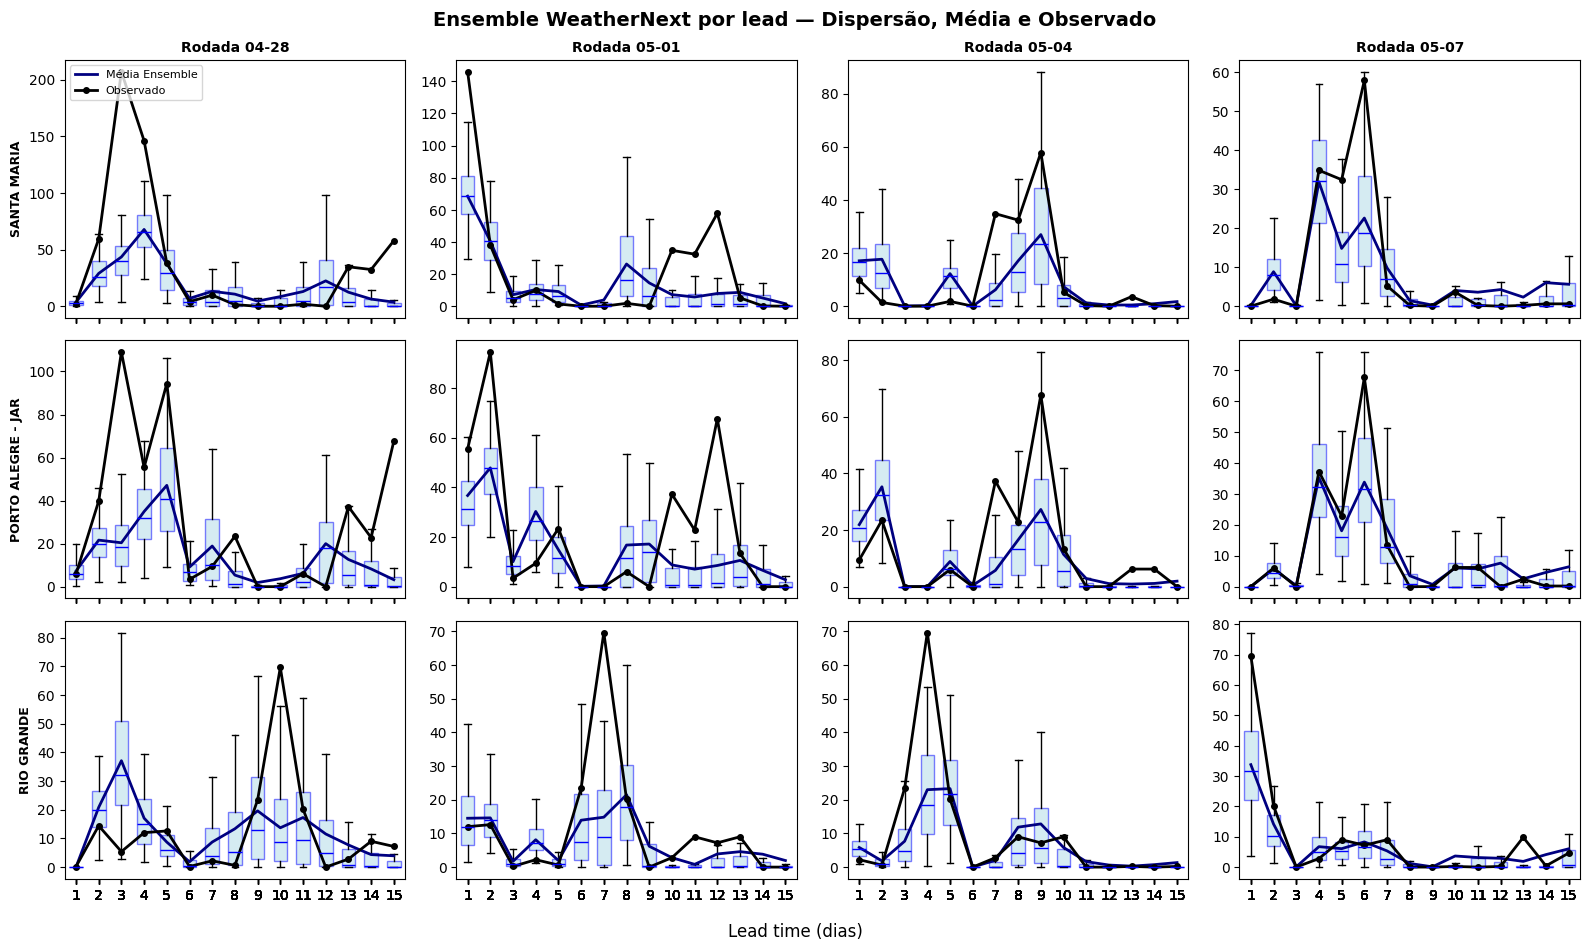

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# print('Estações:', sorted(casos_membros['estacao'].unique()))
# print('Rodadas :', [str(d) for d in sorted(casos_membros['rodada'].dt.date.unique())])

# ================== AJUSTE ==================
ESTACOES    = ['SANTA MARIA', 'PORTO ALEGRE - JARDIM BOTANICO', 'RIO GRANDE']
DIAS_RODADA = ['2024-04-28', '2024-05-01', '2024-05-04', '2024-05-07']          # datas de início
# ===============================================

n_lin, n_col = len(ESTACOES), len(DIAS_RODADA)
fig, eixos = plt.subplots(n_lin, n_col, figsize=(4.0*n_col, 3.2*n_lin), squeeze=False, sharex=True)

for i, est in enumerate(ESTACOES):
    for j, dia in enumerate(DIAS_RODADA):
        eixo = eixos[i][j]
        rod = pd.Timestamp(dia, tz='UTC')
        sel = casos_membros[(casos_membros['estacao'] == est) &
                            (casos_membros['rodada'] == rod)].sort_values('lead_dias')

        if sel.empty:
            eixo.text(0.5, 0.5, 'sem dados', ha='center', va='center', color='gray')
            eixo.set_xticks([])
        else:
            n_membros = max(len(m) for m in sel['membros'])
            sel = sel[sel['membros'].map(len) == n_membros]
            leads = sel['lead_dias'].to_numpy()
            matriz = np.vstack(list(sel['membros']))                 # (n_leads, 64)

            # Correção: O boxplot só precisa ser chamado UMA vez
            eixo.boxplot(list(sel['membros']), positions=leads, widths=0.6,
                         showfliers=False, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', color='blue', alpha=0.5),
                         medianprops=dict(color='blue'))

            # Plot da média do ensemble e do valor observado
            eixo.plot(leads, matriz.mean(axis=1), color='navy', lw=2, label='Média Ensemble')
            eixo.plot(leads, sel['observado'], color='black', lw=2, marker='o', ms=4, label='Observado')
            eixo.grid(alpha=0., linestyle='--')

        if i == 0:
            eixo.set_title('Rodada ' + dia[5:], fontsize=10, fontweight='bold')
        if j == 0:
            eixo.set_ylabel(est[:18], fontsize=9, fontweight='bold')

# Adiciona legenda apenas no primeiro eixo com dados para não poluir
if not casos_membros.empty:
    eixos[0][0].legend(fontsize=8, loc='upper left')

fig.suptitle('Ensemble WeatherNext por lead — Dispersão, Média e Observado', fontsize=14, fontweight='bold')
fig.supxlabel('Lead time (dias)', fontsize=12)
fig.tight_layout()
plt.show()

### Erro por estação e por horizonte (Figuras 4 e 3)

- **Figura 4** — erro acumulado por estação (previsão − observado): onde o modelo mais subestima.
- **Figura 3** — dispersão do erro por horizonte (todas as estações agregadas): o erro cresce com o lead.

Usam `casos_membros` (Seção 6) se existir; senão, `casos_media`.


usando: casos_membros


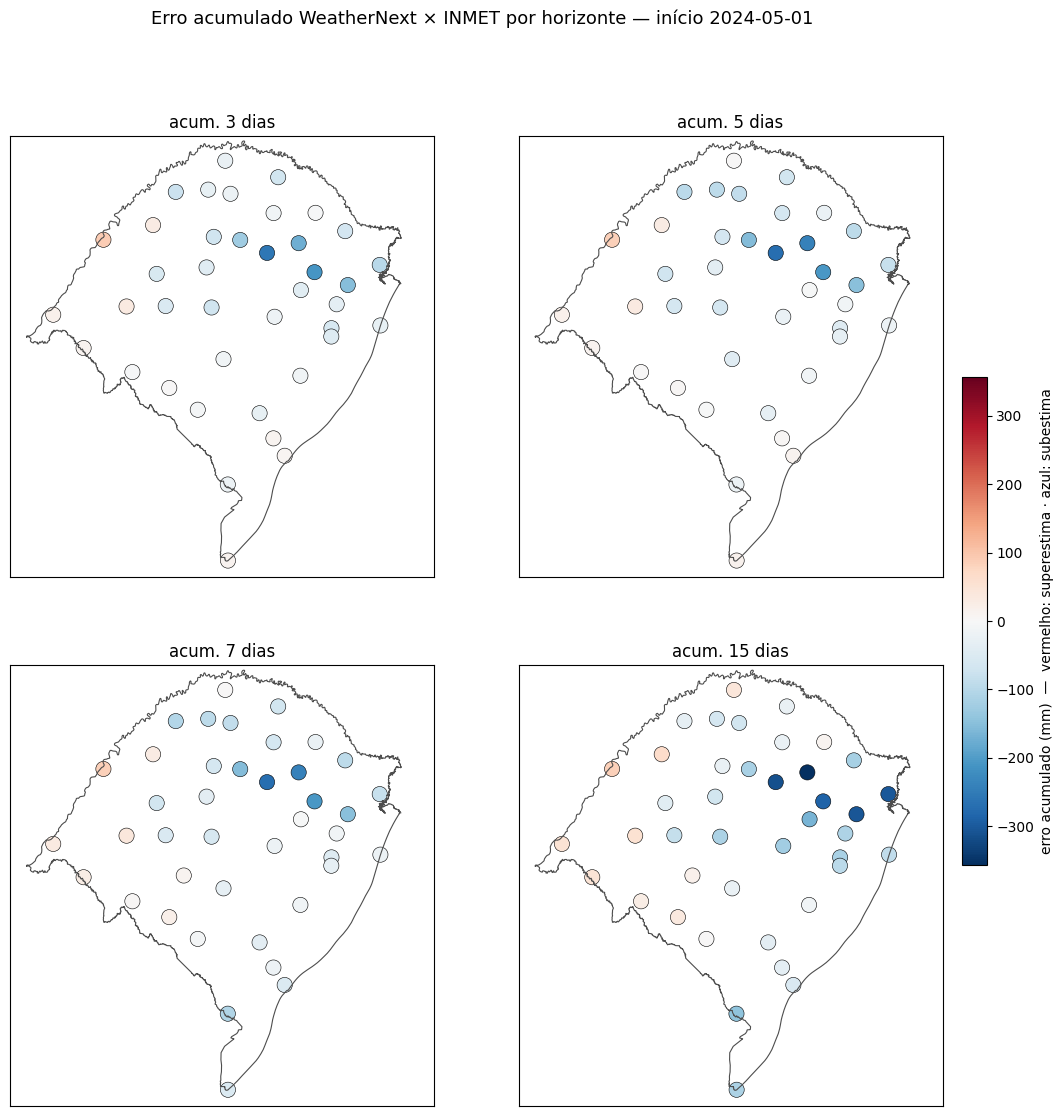

In [ ]:
# ===== matriz de erro por estação, por horizonte — vermelho: superestima | azul: subestima =====
import math
RODADA_INICIO = '2024-05-01'      # <-- decida aqui (tem que existir em CASOS['rodada'])
HORIZONTES    = [3, 5, 7, 15]      # dias acumulados a partir da rodada

_disp = [n for n in ['casos_membros', 'casos_media', 'casos_media_ecmwf'] if n in globals()]
assert _disp, 'Rode a Seção 6 (casos_membros) ou a Seção 5 (casos_media) primeiro.'
CASOS = globals()[_disp[0]]; print('usando:', _disp[0])
rod = pd.Timestamp(RODADA_INICIO, tz='UTC')

if rod not in set(CASOS['rodada']):
    raise ValueError('Rodada não encontrada. Datas disponíveis: '
                     + ', '.join(str(d) for d in sorted(CASOS['rodada'].dt.date.unique())))

dados, lim = {}, 0.0
for H in HORIZONTES:
    g = CASOS[(CASOS['rodada'] == rod) & (CASOS['lead_dias'] <= H)]
    pe = (g.groupby(['estacao', 'lat', 'lon'])
            .agg(obs_acum=('observado', 'sum'), prev_acum=('media_ensemble', 'sum')).reset_index())
    pe['erro'] = pe['prev_acum'] - pe['obs_acum']          # + superestima | − subestima
    dados[H] = pe
    if len(pe): lim = max(lim, float(pe['erro'].abs().max()))

ncol = 2; nlin = math.ceil(len(HORIZONTES) / ncol)
fig, eixos = plt.subplots(nlin, ncol, figsize=(6.3*ncol, 6.3*nlin), squeeze=False)
disp = None
for k, H in enumerate(HORIZONTES):
    eixo = eixos[k // ncol][k % ncol]; pe = dados[H]
    _desenhar_contorno_rs(eixo)
    disp = eixo.scatter(pe['lon'], pe['lat'], c=pe['erro'], s=120, cmap='RdBu_r',
                        vmin=-lim, vmax=lim, edgecolor='k', linewidth=0.4)
    eixo.set_xlim(OESTE, LESTE); eixo.set_ylim(SUL, NORTE); eixo.set_xticks([]); eixo.set_yticks([])
    eixo.set_title(f'acum. {H} dias', fontsize=12)
for k in range(len(HORIZONTES), nlin*ncol):
    eixos[k // ncol][k % ncol].axis('off')
barra = fig.colorbar(disp, ax=eixos, fraction=0.025, pad=0.02)
barra.set_label('erro acumulado (mm)  —  vermelho: superestima · azul: subestima')
fig.suptitle(f'Erro acumulado WeatherNext × INMET por horizonte — início {RODADA_INICIO}', fontsize=13)
plt.savefig('/content/drive/MyDrive/wn2_export/matriz_erro_estacoes.png', dpi=200, bbox_inches='tight')
plt.show()

usando: casos_membros


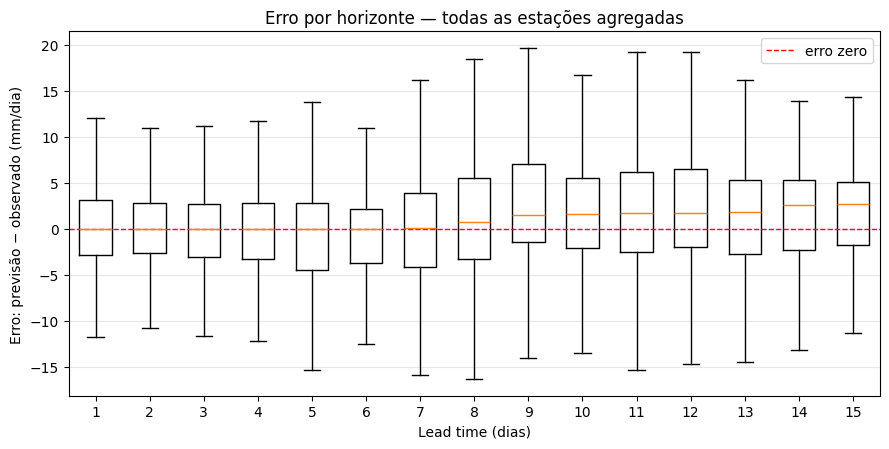

In [ ]:
# ===== boxplot do erro por horizonte (1–15 dias), todas as estações agregadas =====
_disp = [n for n in ['casos_membros', 'casos_media', 'casos_media_ecmwf'] if n in globals()]
assert _disp, 'Rode a Seção 6 (casos_membros) ou a Seção 5 (casos_media) primeiro.'
CASOS = globals()[_disp[0]]; print('usando:', _disp[0])

USAR_MEMBROS = False   # False: erro da média do ensemble | True: erro de TODOS os 64 membros

leads = sorted([l for l in CASOS['lead_dias'].unique() if 1 <= l <= 15])
dados = []
for lead in leads:
    g = CASOS[CASOS['lead_dias'] == lead]
    if USAR_MEMBROS:
        erro = np.concatenate([m - o for m, o in zip(g['membros'], g['observado'])])
    else:
        erro = (g['media_ensemble'] - g['observado']).to_numpy()
    dados.append(erro)

plt.figure(figsize=(9, 4.6))
plt.boxplot(dados, positions=leads, widths=0.6, showfliers=False)
plt.axhline(0, color='red', ls='--', lw=1, label='erro zero')
plt.xticks(leads)
plt.xlabel('Lead time (dias)'); plt.ylabel('Erro: previsão − observado (mm/dia)')
plt.title('Erro por horizonte — todas as estações agregadas')
plt.grid(alpha=0.3, axis='y'); plt.legend(); plt.tight_layout()
plt.savefig('/content/drive/MyDrive/wn2_export/boxplot_erro_por_lead.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Comparação espacial em malha — WeatherNext 2 × IMERG (verdade)

Matriz de isoietas por rodada. **Linhas** = WeatherNext 2 e IMERG (verdade); **colunas** =
rodadas (datas de início), com **horizonte fixo** `HORIZONTE_DIAS`. Cada célula é o acumulado
de `HORIZONTE_DIAS` dias a partir daquela rodada. O filtro `MIN_MM_ISOIETA` esconde a chuva fraca,
e cada fonte fica na sua resolução nativa.

A linha do WeatherNext pode ser a **média** (`WN2_ESTATISTICA='media'`, Figura 5) ou o
**percentil 95** dos 64 membros (`'p95'`, Figura 6 — realça os picos que a média achata).




In [ ]:
from matplotlib.colors import Normalize

# ============ AJUSTE AQUI ============
HORIZONTE_DIAS  = 5        # acumulado de N dias a partir de cada rodada
MIN_MM_ISOIETA  = 5        # só desenha isoietas a partir deste valor (mm) — filtra chuva fraca
RODADAS = ['2024-04-28', '2024-04-30', '2024-05-02', '2024-05-04']   # datas de início (00Z) = colunas
WN2_ESTATISTICA = 'media'  # 'media' (Figura 5) ou 'p95' (Figura 6 — usa os 64 membros; realça os picos)
CAMINHO_FIG = '/content/drive/MyDrive/wn2_export/matriz_rodadas.png'
# =====================================


def rodadas_diarias(inicio, fim):
    """Lista de datas (uma rodada por dia) entre inicio e fim."""
    return [d.strftime('%Y-%m-%d') for d in pd.date_range(inicio, fim, freq='D')]


# O forecast_hour do WN2 pode vir como texto ou número no asset — evita filtro numérico errado.
_exemplo_fh_wn2 = (ee.ImageCollection(WN2_MEDIA)
                   .filterDate(ee.Date(RODADAS[0]), ee.Date(RODADAS[0]).advance(6, 'hour'))
                   .first().get('forecast_hour').getInfo())
FH_WN2_TEXTO = isinstance(_exemplo_fh_wn2, str)


def _no_tipo_wn2(horas):
    return [str(h) for h in horas] if FH_WN2_TEXTO else horas


# ---- Campos ACUMULADOS até o horizonte, cada um na resolução nativa ----
def campo_wn2_acumulado(rodada, dias):
    """WeatherNext 2 (média): acumulado da rodada até 'dias' (soma as janelas de 6 h). ~0,25°."""
    inicio = ee.Date(rodada)
    horas = _no_tipo_wn2(list(range(6, 24 * dias + 1, 6)))
    colecao = (ee.ImageCollection(WN2_MEDIA)
               .filterDate(inicio, inicio.advance(6, 'hour'))
               .filter(ee.Filter.inList('forecast_hour', horas))
               .select(BANDA_PRECIP))
    return colecao.sum().multiply(1000).rename('mm').reproject(colecao.first().projection())


def campo_wn2_percentil(rodada, dias, percentil=95):
    """WeatherNext 2 (percentil dos 64 membros)."""
    inicio = ee.Date(rodada)
    horas = _no_tipo_wn2(list(range(6, 24 * dias + 1, 6)))
    colecao = (ee.ImageCollection(WN2_MEMBROS)
               .filterDate(inicio, inicio.advance(6, 'hour'))
               .filter(ee.Filter.inList('forecast_hour', horas))
               .select(BANDA_PRECIP))
    membros = colecao.aggregate_array('ensemble_member').distinct()

    def acumulado_do_membro(identificador):
        return (colecao.filter(ee.Filter.eq('ensemble_member', identificador))
                .sum().multiply(1000).rename('mm'))

    por_membro = ee.ImageCollection(membros.map(acumulado_do_membro))
    campo = por_membro.reduce(ee.Reducer.percentile([percentil]))       # percentil por pixel entre os membros
    return campo.rename('mm').reproject(colecao.first().projection())


def campo_wn2_campo(rodada, dias):
    """Escolhe o campo do WeatherNext conforme WN2_ESTATISTICA ('media' ou 'p95')."""
    if WN2_ESTATISTICA == 'p95':
        return campo_wn2_percentil(rodada, dias, 95)
    return campo_wn2_acumulado(rodada, dias)


NOME_LINHA_WN2 = 'WeatherNext 2 (p95)' if WN2_ESTATISTICA == 'p95' else 'WeatherNext 2 (média)'


def campo_imerg_acumulado(rodada, dias):
    """IMERG (verdade): acumulado observado da rodada até 'dias'. ~0,1°."""
    inicio = ee.Date(rodada)
    colecao = ee.ImageCollection(IMERG_ASSET).filterDate(inicio, inicio.advance(dias, 'day')).select('precipitation')
    return colecao.mean().multiply(dias * 24).rename('mm').reproject(colecao.first().projection())


def campo_para_grade(imagem):
    """Baixa o campo na resolução NATIVA da imagem + a lon/lat de cada célula (para as isoietas)."""
    coordenadas = ee.Image.pixelLonLat().reproject(imagem.projection())
    amostra = imagem.addBands(coordenadas).sampleRectangle(region=REGIAO_MAPA, defaultValue=0)
    campo = np.array(amostra.get('mm').getInfo(), dtype=float)
    lon = np.array(amostra.get('longitude').getInfo(), dtype=float)
    lat = np.array(amostra.get('latitude').getInfo(), dtype=float)
    return lon, lat, campo


Campos lidos do cache: /content/drive/MyDrive/wn2_export/campos_20240428_20240504_n4_h5_media_semifs.pkl


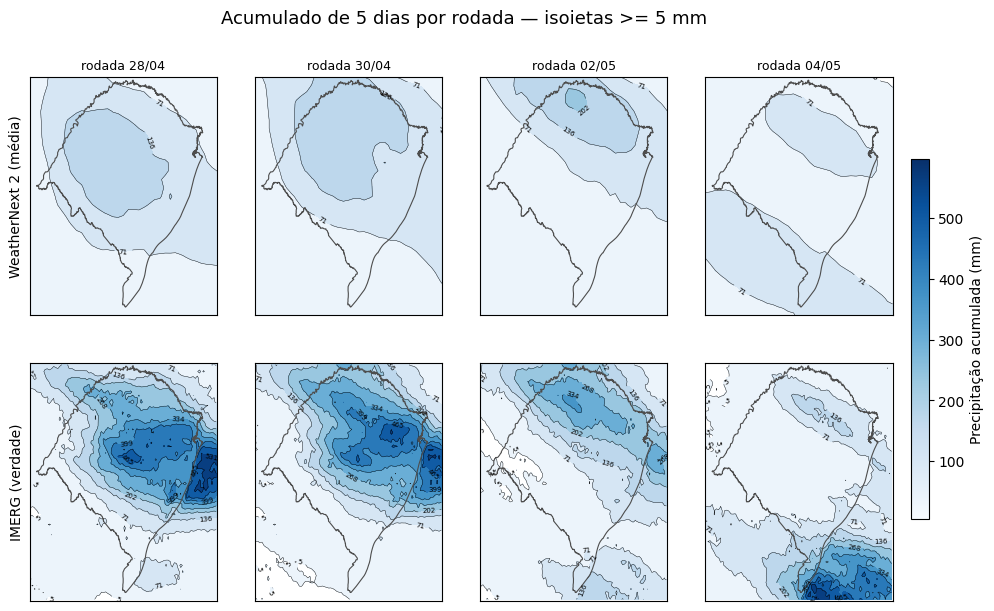

In [ ]:
def figura_matriz_rodadas(rodadas, horizonte_dias, min_mm=5, caminho_saida=None, forcar=False):
    """Matriz de isoietas: linhas = WeatherNext e IMERG; colunas = rodadas. (Sem IFS — evento de 2024.)"""
    fontes = [(NOME_LINHA_WN2, campo_wn2_campo), ('IMERG (verdade)', campo_imerg_acumulado)]

    import pickle
    ini = pd.Timestamp(min(rodadas)).strftime('%Y%m%d'); fim = pd.Timestamp(max(rodadas)).strftime('%Y%m%d')
    caminho_cache = f'/content/drive/MyDrive/wn2_export/campos_{ini}_{fim}_n{len(rodadas)}_h{horizonte_dias}_{WN2_ESTATISTICA}_semifs.pkl'

    if not forcar and os.path.exists(caminho_cache):
        with open(caminho_cache, 'rb') as fca: grades, valor_maximo = pickle.load(fca)
        print('Campos lidos do cache:', caminho_cache)
    else:
        grades, valor_maximo = {}, 0.0
        for rodada in rodadas:
            grades[rodada] = {}
            for nome, construtor in fontes:
                try:
                    lon, lat, campo = campo_para_grade(construtor(rodada, horizonte_dias))
                    valor_maximo = max(valor_maximo, float(np.nanmax(campo)))
                except Exception as erro:
                    print(f'  aviso: {nome} / {rodada} falhou ({erro})'); lon, lat, campo = None, None, None
                grades[rodada][nome] = (lon, lat, campo)
            print(f'  rodada {rodada} pronta')
        with open(caminho_cache, 'wb') as fca: pickle.dump((grades, valor_maximo), fca)
        print('Campos salvos no cache:', caminho_cache)

    niveis = np.linspace(min_mm, max(valor_maximo, min_mm + 1), 10)
    linhas = [f[0] for f in fontes]; n_col = len(rodadas)
    figura, eixos = plt.subplots(len(linhas), n_col, figsize=(2.9*n_col, 3.0*len(linhas)+0.8), squeeze=False)
    for i, nome_linha in enumerate(linhas):
        for j, rodada in enumerate(rodadas):
            eixo = eixos[i][j]; lon, lat, campo = grades[rodada][nome_linha]
            if campo is not None:
                eixo.contourf(lon, lat, campo, levels=niveis, cmap='Blues', extend='max')
                iso = eixo.contour(lon, lat, campo, levels=niveis, colors='k', linewidths=0.3)
                eixo.clabel(iso, inline=True, fontsize=5, fmt='%.0f')
            _desenhar_contorno_rs(eixo)
            eixo.set_xlim(OESTE, LESTE); eixo.set_ylim(SUL, NORTE); eixo.set_xticks([]); eixo.set_yticks([])
            if i == 0: eixo.set_title('rodada ' + pd.Timestamp(rodada).strftime('%d/%m'), fontsize=9)
            if j == 0: eixo.set_ylabel(nome_linha, fontsize=10)
    from matplotlib.colors import Normalize
    escala = plt.cm.ScalarMappable(cmap='Blues', norm=Normalize(min_mm, niveis[-1]))
    figura.colorbar(escala, ax=eixos, fraction=0.02, pad=0.02, label='Precipitação acumulada (mm)')
    figura.suptitle(f'Acumulado de {horizonte_dias} dias por rodada — isoietas >= {min_mm} mm', fontsize=13)
    if caminho_saida: figura.savefig(caminho_saida, dpi=130, bbox_inches='tight')
    plt.show()

figura_matriz_rodadas(RODADAS, HORIZONTE_DIAS, min_mm=MIN_MM_ISOIETA, caminho_saida=CAMINHO_FIG)


===== horizonte 3 dias =====
Campos lidos do cache: /content/drive/MyDrive/wn2_export/campos_20240428_20240504_n4_h3_media_semifs.pkl


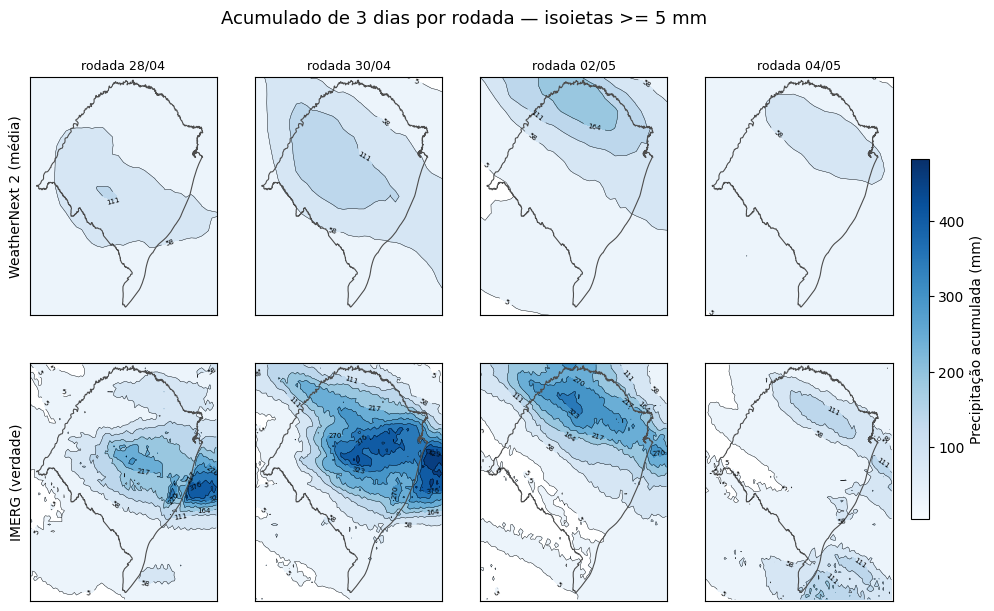


===== horizonte 5 dias =====
Campos lidos do cache: /content/drive/MyDrive/wn2_export/campos_20240428_20240504_n4_h5_media_semifs.pkl


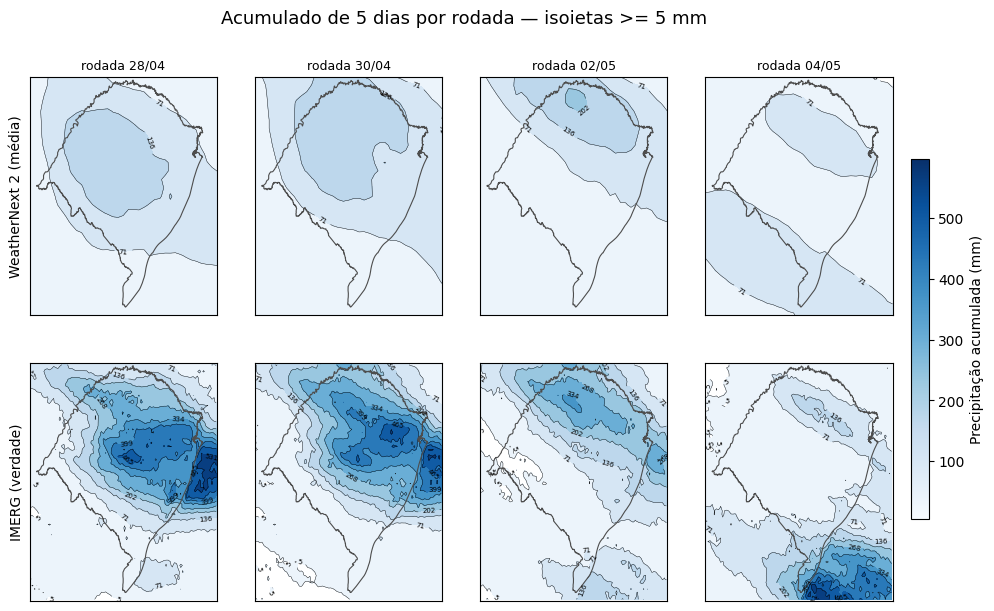


===== horizonte 10 dias =====
Campos lidos do cache: /content/drive/MyDrive/wn2_export/campos_20240428_20240504_n4_h10_media_semifs.pkl


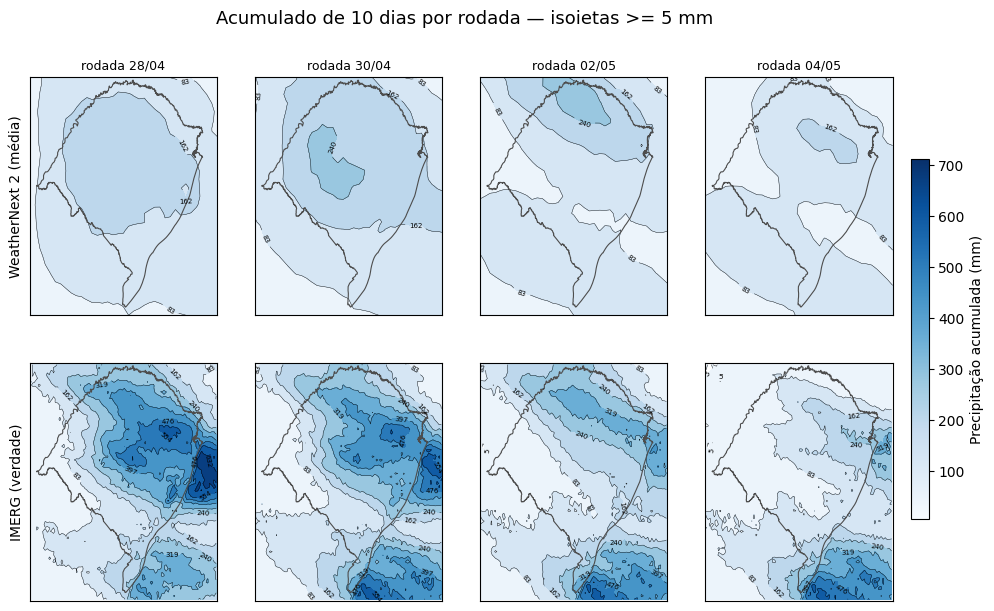

In [ ]:

for horizonte in [3, 5, 10]:
    print(f'\n===== horizonte {horizonte} dias =====')
    figura_matriz_rodadas(
        RODADAS, horizonte, min_mm=MIN_MM_ISOIETA,
        caminho_saida=f'/content/drive/MyDrive/wn2_export/matriz_rodadas_h{horizonte}.png')


### Probabilidade de excedência (Figura 7)

Fração dos 64 membros que ultrapassa um limiar, por pixel, confrontada com onde o IMERG de
fato excedeu (contorno vermelho). Abaixo, os limiares de 200 mm e 400 mm no acumulado de 5 dias.


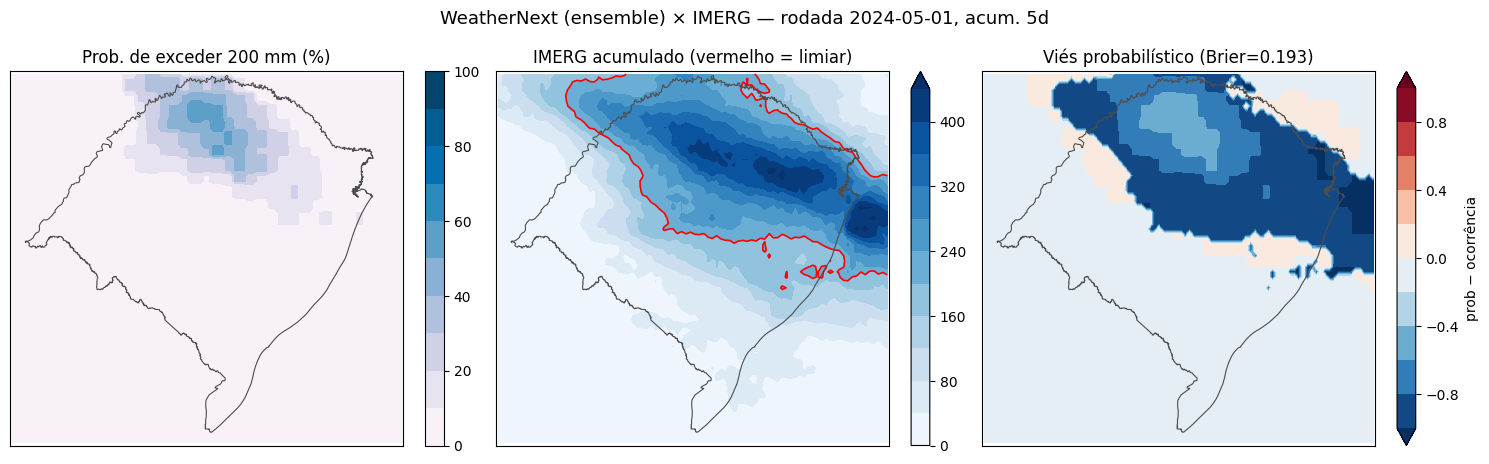

In [ ]:
RODADA_PROB = '2024-05-01'
DIAS_PROB   = HORIZONTE_DIAS
LIMIAR_PROB = 200         # mm em DIAS_PROB dias

_t = [0.1, 0, OESTE, 0, -0.1, NORTE]

def _campo_prob_excedencia(rodada, dias, limiar_mm):
    inicio = ee.Date(rodada)
    col = (ee.ImageCollection(WN2_MEMBROS)
           .filterDate(inicio, inicio.advance(6, 'hour')).select(BANDA_PRECIP))
    if col.size().getInfo() == 0:
        raise ValueError(f'WeatherNext (membros) sem a rodada {rodada}. Escolha uma data coberta.')
    exemplo = col.first().get('forecast_hour').getInfo()          # tipo no asset DOS MEMBROS
    horas = list(range(6, 24*dias+1, 6))
    if isinstance(exemplo, str):
        horas = [str(h) for h in horas]
    col = col.filter(ee.Filter.inList('forecast_hour', horas))
    membros = col.aggregate_array('ensemble_member').distinct()
    def excede(m):
        return col.filter(ee.Filter.eq('ensemble_member', m)).sum().multiply(1000).gte(limiar_mm)
    return ee.ImageCollection(membros.map(excede)).mean().rename('mm')

img_prob  = _campo_prob_excedencia(RODADA_PROB, DIAS_PROB, LIMIAR_PROB).reproject(crs='EPSG:4326', crsTransform=_t)
img_imerg = campo_imerg_acumulado(RODADA_PROB, DIAS_PROB).reproject(crs='EPSG:4326', crsTransform=_t)
lon, lat, prob  = campo_para_grade(img_prob)
_,   _,   imerg = campo_para_grade(img_imerg)

ocorreu   = (imerg >= LIMIAR_PROB).astype(float)
vies_prob = prob - ocorreu
brier     = float(np.mean((prob - ocorreu) ** 2))

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.6))
c0 = eixos[0].contourf(lon, lat, prob*100, levels=np.linspace(0,100,11), cmap='PuBu')
eixos[0].set_title(f'Prob. de exceder {LIMIAR_PROB} mm (%)'); fig.colorbar(c0, ax=eixos[0], fraction=0.045)
c1 = eixos[1].contourf(lon, lat, imerg, levels=11, cmap='Blues', extend='max')
eixos[1].contour(lon, lat, imerg, levels=[LIMIAR_PROB], colors='red', linewidths=1.2)
eixos[1].set_title('IMERG acumulado (vermelho = limiar)'); fig.colorbar(c1, ax=eixos[1], fraction=0.045)
c2 = eixos[2].contourf(lon, lat, vies_prob, levels=np.linspace(-1,1,11), cmap='RdBu_r', extend='both')
eixos[2].set_title(f'Viés probabilístico (Brier={brier:.3f})'); fig.colorbar(c2, ax=eixos[2], fraction=0.045, label='prob − ocorrência')
for e in eixos:
    _desenhar_contorno_rs(e); e.set_xlim(OESTE, LESTE); e.set_ylim(SUL, NORTE); e.set_xticks([]); e.set_yticks([])
fig.suptitle(f'WeatherNext (ensemble) × IMERG — rodada {RODADA_PROB}, acum. {DIAS_PROB}d', fontsize=13)
fig.tight_layout(); plt.show()

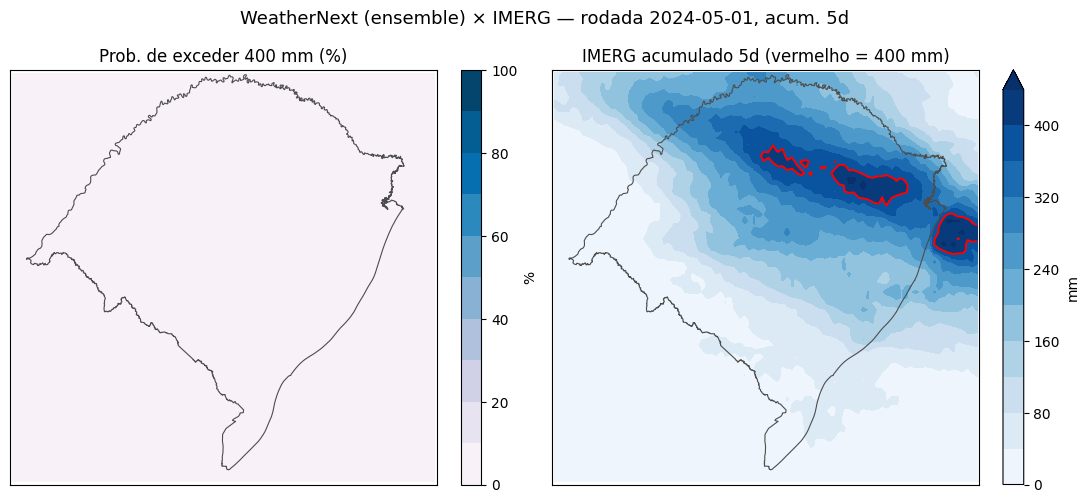

In [ ]:
RODADA_PROB = '2024-05-01'
DIAS_PROB   = HORIZONTE_DIAS
LIMIAR_PROB = 400

_t = [0.1, 0, OESTE, 0, -0.1, NORTE]

def _campo_prob_excedencia(rodada, dias, limiar_mm):
    inicio = ee.Date(rodada)
    col = (ee.ImageCollection(WN2_MEMBROS)
           .filterDate(inicio, inicio.advance(6, 'hour')).select(BANDA_PRECIP))
    if col.size().getInfo() == 0:
        raise ValueError(f'WeatherNext (membros) sem a rodada {rodada}. Escolha uma data coberta.')
    exemplo = col.first().get('forecast_hour').getInfo()
    horas = list(range(6, 24*dias+1, 6))
    if isinstance(exemplo, str):
        horas = [str(h) for h in horas]
    col = col.filter(ee.Filter.inList('forecast_hour', horas))
    membros = col.aggregate_array('ensemble_member').distinct()
    def excede(m):
        return col.filter(ee.Filter.eq('ensemble_member', m)).sum().multiply(1000).gte(limiar_mm)
    return ee.ImageCollection(membros.map(excede)).mean().rename('mm')

img_prob  = _campo_prob_excedencia(RODADA_PROB, DIAS_PROB, LIMIAR_PROB).reproject(crs='EPSG:4326', crsTransform=_t)
img_imerg = campo_imerg_acumulado(RODADA_PROB, DIAS_PROB).reproject(crs='EPSG:4326', crsTransform=_t)
lon, lat, prob  = campo_para_grade(img_prob)
_,   _,   imerg = campo_para_grade(img_imerg)

fig, eixos = plt.subplots(1, 2, figsize=(11, 5))
c0 = eixos[0].contourf(lon, lat, prob*100, levels=np.linspace(0, 100, 11), cmap='PuBu')
eixos[0].set_title(f'Prob. de exceder {LIMIAR_PROB} mm (%)'); fig.colorbar(c0, ax=eixos[0], fraction=0.045, label='%')
c1 = eixos[1].contourf(lon, lat, imerg, levels=11, cmap='Blues', extend='max')
eixos[1].contour(lon, lat, imerg, levels=[LIMIAR_PROB], colors='red', linewidths=1.4)
eixos[1].set_title(f'IMERG acumulado {DIAS_PROB}d (vermelho = {LIMIAR_PROB} mm)'); fig.colorbar(c1, ax=eixos[1], fraction=0.045, label='mm')
for e in eixos:
    _desenhar_contorno_rs(e); e.set_xlim(OESTE, LESTE); e.set_ylim(SUL, NORTE); e.set_xticks([]); e.set_yticks([])
fig.suptitle(f'WeatherNext (ensemble) × IMERG — rodada {RODADA_PROB}, acum. {DIAS_PROB}d', fontsize=13)
fig.tight_layout()
fig.savefig('/content/drive/MyDrive/wn2_export/prob_excedencia.png', dpi=200, bbox_inches='tight')
plt.show()

### Figura 1 — chuva acumulada do IMERG no evento

Mapa de isoietas da chuva estimada pelo IMERG entre 27/04 e 14/05/2024 (a banda intensa da cheia).


Figura salva em /content/drive/MyDrive/wn2_export/figura1_imerg_evento.png | máx = 931.0 mm


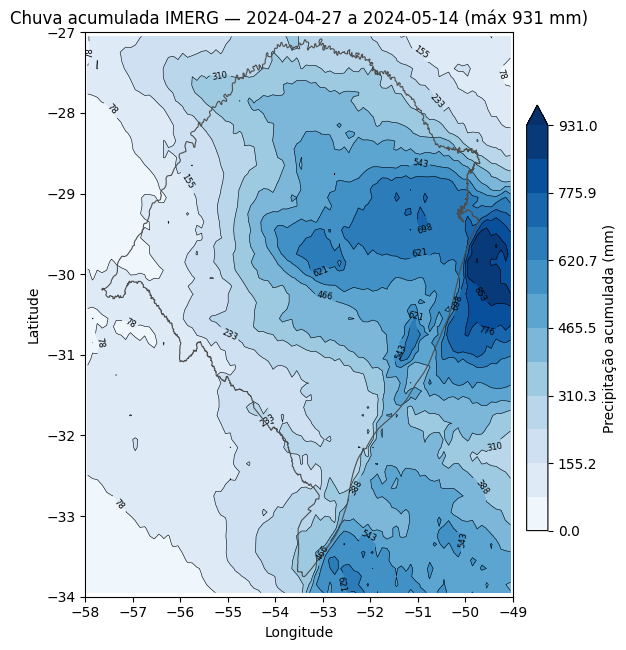

In [ ]:
# ===== Figura 1: chuva acumulada do IMERG no evento de 2024 (isoietas) =====
EVENTO_INI = '2024-04-27'     # início do acúmulo
EVENTO_FIM = '2024-05-14'     # fim (exclusivo) — cobre até 13/05
CAMINHO_FIG1 = '/content/drive/MyDrive/wn2_export/figura1_imerg_evento.png'

def imerg_acumulado_periodo(data_inicio, data_fim):
    """Chuva IMERG acumulada (mm) entre duas datas (taxa média x horas do período)."""
    col = (ee.ImageCollection(IMERG_ASSET).filterDate(data_inicio, data_fim)
           .filterBounds(CAIXA_RS).select('precipitation'))            # mm/h (meia-hora)
    n_horas = ee.Date(data_fim).difference(ee.Date(data_inicio), 'hour')
    return col.mean().multiply(n_horas).rename('mm').reproject(col.first().projection())

# baixa o campo na resolução nativa (~0,1°), com coordenadas reais
lon, lat, campo = campo_para_grade(imerg_acumulado_periodo(EVENTO_INI, EVENTO_FIM))

vmax = float(np.nanmax(campo))
niveis = np.linspace(0, vmax, 13)

fig, eixo = plt.subplots(figsize=(6.2, 6.6))
cf = eixo.contourf(lon, lat, campo, levels=niveis, cmap='Blues', extend='max')
iso = eixo.contour(lon, lat, campo, levels=niveis, colors='k', linewidths=0.4)
eixo.clabel(iso, inline=True, fontsize=6, fmt='%.0f')                  # rótulos das isoietas (mm)
_desenhar_contorno_rs(eixo)                                            # contorno do RS
eixo.set_xlim(OESTE, LESTE); eixo.set_ylim(SUL, NORTE)
eixo.set_xlabel('Longitude'); eixo.set_ylabel('Latitude')
eixo.set_title(f'Chuva acumulada IMERG — {EVENTO_INI} a {EVENTO_FIM} (máx {vmax:.0f} mm)')
barra = fig.colorbar(cf, ax=eixo, fraction=0.046, pad=0.03)
barra.set_label('Precipitação acumulada (mm)')
fig.tight_layout()
fig.savefig(CAMINHO_FIG1, dpi=300, bbox_inches='tight')                # PNG para o artigo
print('Figura salva em', CAMINHO_FIG1, '| máx =', round(vmax, 1), 'mm')
plt.show()